## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



### Physics-Informed Machine Learning for Power Electronics Modeling and Design
  * Artificial Toy Example
    * $a^{1.5} + b^{2.5} = c^2$
    * Predicts c given a and b
  * PINN illustrative cases: Temperature annealing equation
    * 1. $T(t) = T_{\infty} + (T_0 - T_{\infty}) e^{-kt}$
    * 2. $\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$  (Burgers' equation)
  * PINN case 2: Fluid and thermal dynamics in a 2-D heat sink
  * Physics-in-architecture neural network - for DAB converters and its variants
    1. PANN inference and training
    2. PANN flexibility - Operating conditions, modulation, circuit parameters, topology
    3. PANN for buck converters

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Toy Example to Understand Priori Knowledge
* $a^{1.5} + b^{2.5} = c^2$
* Task: Predicts c given a and b

##### 1.1 Generate Artificial Dataset

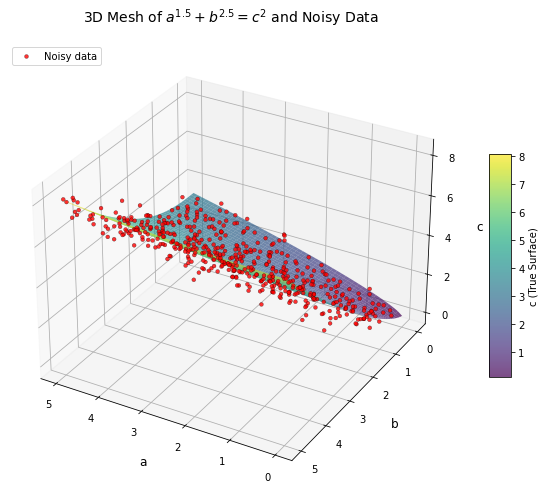

In [2]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 500

# Generate inputs, a and b, uniformly in [0, 5]
a = np.random.uniform(0, 5, n_samples)
b = np.random.uniform(0, 5, n_samples)

# Compute c from the formula: a^1.5 + b^2.5 = c^2 => c = sqrt(a^1.5 + b^2.5)
# generate the label c
c = np.sqrt(np.power(a, 1.5) + np.power(b, 2.5))

# Add Gaussian noise to a, b, and c
a_noisy = a + np.random.normal(0, 0.25, n_samples)
b_noisy = b + np.random.normal(0, 0.25, n_samples)
c_noisy = c + np.random.normal(0, 0.25, n_samples)

# Optionally, clip to keep within valid range
a_noisy = np.clip(a_noisy, 0, 5)
b_noisy = np.clip(b_noisy, 0, 5)
c_noisy = np.clip(c_noisy, 0, None)  # c should be >= 0

# Create a DataFrame for convenience
df = pd.DataFrame({
    'a': a_noisy,
    'b': b_noisy,
    'c': c_noisy
})

# Show the first few rows
df.head()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for a and b
a_lin = np.linspace(0, 5, 50)
b_lin = np.linspace(0, 5, 50)
A, B = np.meshgrid(a_lin, b_lin)
C = np.sqrt(np.power(A, 1.5) + np.power(B, 2.5))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the mesh surface for the true function
surf = ax.plot_surface(A, B, C, cmap='viridis', alpha=0.7, edgecolor='none', linewidth=0, antialiased=True)

# Plot the noisy data as scatter points
ax.scatter(df['a'], df['b'], df['c'], color='r', s=15, label='Noisy data', alpha=0.8, edgecolor='k', linewidth=0.3)

# Styling
ax.set_xlabel('a', fontsize=12, labelpad=10)
ax.set_ylabel('b', fontsize=12, labelpad=10)
ax.set_zlabel('c', fontsize=12, labelpad=10)
ax.set_title('3D Mesh of $a^{1.5} + b^{2.5} = c^2$ and Noisy Data', fontsize=14, pad=20)
ax.view_init(elev=30, azim=120)
fig.colorbar(surf, shrink=0.5, aspect=10, label='c (True Surface)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


##### 1.2 Train a Feedforward Neural Network (Classic)

Epoch 50/2000, Train Loss: 0.2357, Val Loss: 0.3670, LR: 0.020000
Epoch 100/2000, Train Loss: 0.0817, Val Loss: 0.2655, LR: 0.020000
Epoch 150/2000, Train Loss: 0.0667, Val Loss: 0.2676, LR: 0.020000
Epoch 200/2000, Train Loss: 0.0605, Val Loss: 0.2651, LR: 0.010000
Epoch 250/2000, Train Loss: 0.0587, Val Loss: 0.2705, LR: 0.010000
Epoch 300/2000, Train Loss: 0.0570, Val Loss: 0.2729, LR: 0.010000
Epoch 350/2000, Train Loss: 0.0552, Val Loss: 0.2733, LR: 0.010000
Epoch 400/2000, Train Loss: 0.0537, Val Loss: 0.2768, LR: 0.005000
Epoch 450/2000, Train Loss: 0.0531, Val Loss: 0.2784, LR: 0.005000
Epoch 500/2000, Train Loss: 0.0525, Val Loss: 0.2789, LR: 0.005000
Epoch 550/2000, Train Loss: 0.0520, Val Loss: 0.2806, LR: 0.005000
Epoch 600/2000, Train Loss: 0.0515, Val Loss: 0.2816, LR: 0.002500
Epoch 650/2000, Train Loss: 0.0512, Val Loss: 0.2827, LR: 0.002500
Epoch 700/2000, Train Loss: 0.0510, Val Loss: 0.2836, LR: 0.002500
Epoch 750/2000, Train Loss: 0.0507, Val Loss: 0.2848, LR: 0.002

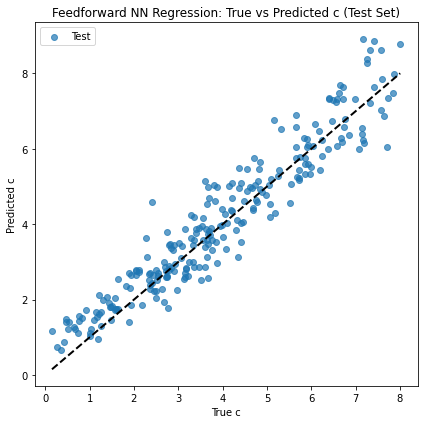

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.02)

# Learning rate scheduler: reduce LR by 50% every 200 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

# Training loop with validation and checkpointing
epochs = 2000
best_val_loss = float('inf')
best_model_state = None

def zscore_weights(module):
    # Z-score (standardize) the weights of all Linear layers in-place
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Z-score the weights after optimizer step
    zscore_weights(model)
    
    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, LR: {current_lr:.6f}")

# Load best model
model.load_state_dict(best_model_state)

# Evaluate on all datasets
model.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression: True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()


##### 1.3 Train a Feedforward Neural Network with Integrated Physics

Epoch 50/4000, Train Loss: 0.8781 (Data: 0.2437, Phys: 6.3441), Val Loss: 1.1792, Exponent p: 1.6771, LR: 0.050000
Epoch 100/4000, Train Loss: 0.2448 (Data: 0.1774, Phys: 0.6734), Val Loss: 0.5346, Exponent p: 1.6345, LR: 0.050000
Epoch 150/4000, Train Loss: 0.2219 (Data: 0.1669, Phys: 0.5499), Val Loss: 0.5573, Exponent p: 1.6141, LR: 0.050000
Epoch 200/4000, Train Loss: 0.2071 (Data: 0.1598, Phys: 0.4731), Val Loss: 0.4655, Exponent p: 1.5956, LR: 0.050000
Epoch 250/4000, Train Loss: 0.1940 (Data: 0.1543, Phys: 0.3968), Val Loss: 0.4323, Exponent p: 1.5794, LR: 0.050000
Epoch 300/4000, Train Loss: 0.1810 (Data: 0.1505, Phys: 0.3051), Val Loss: 0.3886, Exponent p: 1.5659, LR: 0.050000
Epoch 350/4000, Train Loss: 0.1730 (Data: 0.1487, Phys: 0.2435), Val Loss: 0.4165, Exponent p: 1.5550, LR: 0.050000
Epoch 400/4000, Train Loss: 0.1631 (Data: 0.1476, Phys: 0.1545), Val Loss: 0.3631, Exponent p: 1.5462, LR: 0.025000
Epoch 450/4000, Train Loss: 0.1606 (Data: 0.1456, Phys: 0.1504), Val Loss

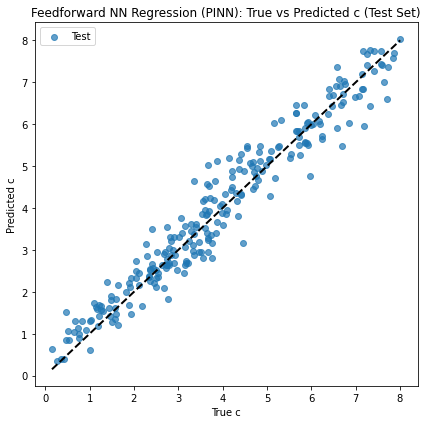

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Also keep unscaled a, b for physics loss (from original X_train, X_val, X_test)
a_train = torch.tensor(X_train[:, 0], dtype=torch.float32).reshape(-1, 1)
b_train = torch.tensor(X_train[:, 1], dtype=torch.float32).reshape(-1, 1)
a_val = torch.tensor(X_val[:, 0], dtype=torch.float32).reshape(-1, 1)
b_val = torch.tensor(X_val[:, 1], dtype=torch.float32).reshape(-1, 1)
a_test = torch.tensor(X_test[:, 0], dtype=torch.float32).reshape(-1, 1)
b_test = torch.tensor(X_test[:, 1], dtype=torch.float32).reshape(-1, 1)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Make the exponent of a a trainable parameter
class PhysicsExponent(nn.Module):
    def __init__(self, init_value=1.5):
        super().__init__()
        self.exponent = nn.Parameter(torch.tensor(float(init_value)))
    def forward(self):
        return self.exponent

physics_exponent = PhysicsExponent(init_value=2.5)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(list(model.parameters()) + list(physics_exponent.parameters()), lr=0.05)

# Learning rate scheduler: reduce LR by 50% every 200 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.5)

# Physics-Informed Loss: a^p + b^2.5 = c^2, where p is trainable
def physics_loss(a, b, c_pred, p):
    lhs = torch.pow(a, p) + torch.pow(b, 2.5)
    rhs = torch.pow(c_pred, 2)
    return torch.mean((lhs - rhs) ** 2)

# Z-score (standardize) the weights of all Linear layers in-place
def zscore_weights(module):
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

# Training loop with validation and checkpointing
epochs = 4000
best_val_loss = float('inf')
best_model_state = None
best_exponent_state = None

lambda_phys = 0.1  # Weight for physics loss, can be tuned

for epoch in range(epochs):
    model.train()
    physics_exponent.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    # Data loss
    data_loss = criterion(outputs, y_train_tensor)
    # Physics loss (use unscaled a, b, and predicted c, and trainable exponent)
    p = physics_exponent()
    phys_loss = physics_loss(a_train, b_train, outputs, p)
    # Total loss
    loss = data_loss + lambda_phys * phys_loss
    loss.backward()
    optimizer.step()

    # Z-score the weights after optimizer step
    zscore_weights(model)

    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    physics_exponent.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_p = physics_exponent()
        val_data_loss = criterion(val_outputs, y_val_tensor)
        val_phys_loss = physics_loss(a_val, b_val, val_outputs, val_p)
        val_loss = val_data_loss + lambda_phys * val_phys_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
        best_exponent_state = physics_exponent.state_dict()  # Save best exponent
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f} (Data: {data_loss.item():.4f}, Phys: {phys_loss.item():.4f}), Val Loss: {val_loss.item():.4f}, Exponent p: {p.item():.4f}, LR: {current_lr:.6f}")

# Load best model and exponent
model.load_state_dict(best_model_state)
physics_exponent.load_state_dict(best_exponent_state)

# Evaluate on all datasets
model.eval()
physics_exponent.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Learned exponent p: {physics_exponent().item():.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression (PINN): True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()


##### 1.4 Train a Feedforward Neural Network with Wrong Integrated Physics

Epoch 50/4000, Train Loss: 201.6853 (Data: 159.6273, Phys: 420.5796), Val Loss: 186.7831, Exponent p: 1.5498, LR: 0.050000
Epoch 100/4000, Train Loss: 170.8495 (Data: 158.6987, Phys: 121.5075), Val Loss: 162.7437, Exponent p: 1.5086, LR: 0.050000
Epoch 150/4000, Train Loss: 163.9584 (Data: 154.3114, Phys: 96.4697), Val Loss: 155.7793, Exponent p: 1.4776, LR: 0.050000
Epoch 200/4000, Train Loss: 158.2146 (Data: 149.8516, Phys: 83.6303), Val Loss: 146.2542, Exponent p: 1.4426, LR: 0.050000
Epoch 250/4000, Train Loss: 152.3466 (Data: 144.4207, Phys: 79.2588), Val Loss: 140.4249, Exponent p: 1.4034, LR: 0.050000
Epoch 300/4000, Train Loss: 146.3998 (Data: 139.2378, Phys: 71.6203), Val Loss: 135.7246, Exponent p: 1.3601, LR: 0.050000
Epoch 350/4000, Train Loss: 140.4892 (Data: 134.1116, Phys: 63.7755), Val Loss: 128.9953, Exponent p: 1.3134, LR: 0.050000
Epoch 400/4000, Train Loss: 134.3619 (Data: 128.1586, Phys: 62.0334), Val Loss: 120.7598, Exponent p: 1.2641, LR: 0.025000
Epoch 450/4000,

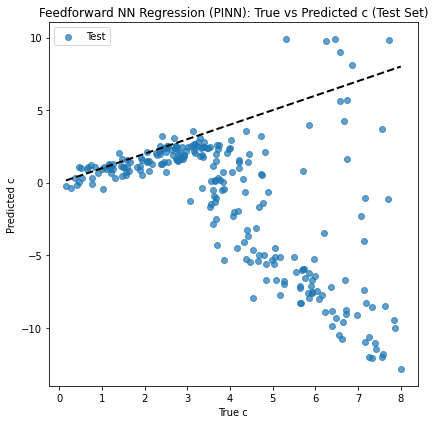

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df[['a', 'b']].values.astype(np.float32)
y = df['c'].values.astype(np.float32).reshape(-1, 1)

# Split into train, val, and test sets (e.g., 10% train, 40% val, 50% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.8, random_state=42) 

# Standardize features (fit only on train, transform all)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Do NOT scale y
y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Also keep unscaled a, b for physics loss (from original X_train, X_val, X_test)
a_train = torch.tensor(X_train[:, 0], dtype=torch.float32).reshape(-1, 1)
b_train = torch.tensor(X_train[:, 1], dtype=torch.float32).reshape(-1, 1)
a_val = torch.tensor(X_val[:, 0], dtype=torch.float32).reshape(-1, 1)
b_val = torch.tensor(X_val[:, 1], dtype=torch.float32).reshape(-1, 1)
a_test = torch.tensor(X_test[:, 0], dtype=torch.float32).reshape(-1, 1)
b_test = torch.tensor(X_test[:, 1], dtype=torch.float32).reshape(-1, 1)

# Define a feedforward neural network with BatchNorm
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.BatchNorm1d(10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        return self.net(x)

model = FeedforwardNN()

# Make the exponent of a a trainable parameter
class PhysicsExponent(nn.Module):
    def __init__(self, init_value=1.5):
        super().__init__()
        self.exponent = nn.Parameter(torch.tensor(float(init_value)))
    def forward(self):
        return self.exponent

physics_exponent = PhysicsExponent(init_value=2.5)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(list(model.parameters()) + list(physics_exponent.parameters()), lr=0.05)

# Learning rate scheduler: reduce LR by 50% every 200 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.5)

# Physics-Informed Loss: a^p + b^2.5 = c^2, where p is trainable
def physics_loss(a, b, c_pred, p):
    # intentionally wrong physics loss
    lhs = torch.pow(a, p) * torch.pow(b, 2.5)
    rhs = torch.pow(c_pred, 2)
    return torch.mean((lhs - rhs) ** 2)

# Z-score (standardize) the weights of all Linear layers in-place
def zscore_weights(module):
    for m in module.modules():
        if isinstance(m, nn.Linear):
            with torch.no_grad():
                w = m.weight.data
                mean = w.mean()
                std = w.std()
                if std > 0:
                    m.weight.data = (w - mean) / std

# Training loop with validation and checkpointing
epochs = 4000
best_val_loss = float('inf')
best_model_state = None
best_exponent_state = None

lambda_phys = 0.1  # Weight for physics loss, can be tuned

for epoch in range(epochs):
    model.train()
    physics_exponent.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    # Data loss
    data_loss = criterion(outputs, y_train_tensor)
    # Physics loss (use unscaled a, b, and predicted c, and trainable exponent)
    p = physics_exponent()
    phys_loss = physics_loss(a_train, b_train, outputs, p)
    # Total loss
    loss = data_loss + lambda_phys * phys_loss
    loss.backward()
    optimizer.step()

    # Z-score the weights after optimizer step
    zscore_weights(model)

    # Step the learning rate scheduler
    scheduler.step()
    
    # Validation
    model.eval()
    physics_exponent.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_p = physics_exponent()
        val_data_loss = criterion(val_outputs, y_val_tensor)
        val_phys_loss = physics_loss(a_val, b_val, val_outputs, val_p)
        val_loss = val_data_loss + lambda_phys * val_phys_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()  # Save best model weights
        best_exponent_state = physics_exponent.state_dict()  # Save best exponent
    
    if (epoch+1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f} (Data: {data_loss.item():.4f}, Phys: {phys_loss.item():.4f}), Val Loss: {val_loss.item():.4f}, Exponent p: {p.item():.4f}, LR: {current_lr:.6f}")

# Load best model and exponent
model.load_state_dict(best_model_state)
physics_exponent.load_state_dict(best_exponent_state)

# Evaluate on all datasets
model.eval()
physics_exponent.eval()
with torch.no_grad():
    # Train set
    y_train_pred = model(X_train_tensor).numpy()
    y_train_true = y_train_tensor.numpy()
    train_mse = np.mean((y_train_pred - y_train_true) ** 2)
    # Validation set
    y_val_pred = model(X_val_tensor).numpy()
    y_val_true = y_val_tensor.numpy()
    val_mse = np.mean((y_val_pred - y_val_true) ** 2)
    # Test set
    y_test_pred = model(X_test_tensor).numpy()
    y_test_true = y_test_tensor.numpy()
    test_mse = np.mean((y_test_pred - y_test_true) ** 2)
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Validation MSE: {val_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Learned exponent p: {physics_exponent().item():.4f}")

# Optionally, plot predictions vs true values for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred, alpha=0.7, label='Test')
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'k--', lw=2)
plt.xlabel('True c')
plt.ylabel('Predicted c')
plt.title('Feedforward NN Regression (PINN): True vs Predicted c (Test Set)')
plt.tight_layout()
plt.legend()
plt.show()
